# CWRU Spectrogram Augmentation Figure Maker

이 노트북은 보고서에 넣을 수 있는 **데이터 증강 예시 피규어**를 생성한다.

생성되는 대표 피규어:

- `fig_augmentation_examples_single_label.png`
- `fig_augmentation_examples_multiple_labels.png`
- `fig_augmentation_strength_comparison.png`

기본 입력은 앞에서 만든 컬러 스펙트로그램 데이터셋이다.

```text
cwru_spectrogram_training_dataset/
 ├─ dataset_images/
 ├─ metadata.csv
 └─ split_dataset/
```


In [1]:
# 필요한 라이브러리
# 에러가 나면 아래 주석을 해제해서 설치하면 된다.
# !pip install numpy pandas matplotlib pillow

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 경로 설정

`DATASET_ROOT`는 `metadata.csv`가 들어있는 폴더로 설정하면 된다.

만약 현재 노트북과 데이터셋 폴더가 같은 위치에 있다면 기본값 그대로 실행하면 된다.

In [2]:
# =========================
# 사용자가 수정할 설정
# =========================

DATASET_ROOT = Path("./cwru_spectrogram_training_dataset")
METADATA_PATH = DATASET_ROOT / "metadata.csv"
FIGURE_DIR = DATASET_ROOT / "report_figures"

# 보고서용 피규어 해상도
DPI = 300

# 랜덤 seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT.resolve())
print("METADATA_PATH:", METADATA_PATH.resolve())
print("FIGURE_DIR:", FIGURE_DIR.resolve())

DATASET_ROOT: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset
METADATA_PATH: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\metadata.csv
FIGURE_DIR: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures


## 2. 데이터셋 확인

`metadata.csv`를 읽고 이미지 경로가 정상인지 확인한다.

In [3]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f"metadata.csv를 찾을 수 없습니다: {METADATA_PATH}\n"
        "DATASET_ROOT 경로를 확인하세요."
    )

metadata_df = pd.read_csv(METADATA_PATH)
print("총 이미지 수:", len(metadata_df))
print("컬럼:", metadata_df.columns.tolist())

# image_path가 상대경로라면 DATASET_ROOT 기준으로 해석한다.
def resolve_image_path(p):
    p = Path(str(p))
    if p.is_absolute():
        return p
    return DATASET_ROOT / p

metadata_df["resolved_path"] = metadata_df["image_path"].apply(resolve_image_path)
metadata_df["exists"] = metadata_df["resolved_path"].apply(lambda p: p.exists())

print("존재하는 이미지 수:", int(metadata_df["exists"].sum()))
if metadata_df["exists"].sum() == 0:
    raise FileNotFoundError("metadata.csv는 읽었지만 실제 이미지 파일을 찾지 못했습니다. DATASET_ROOT를 확인하세요.")

display(metadata_df.head())

총 이미지 수: 3154
컬럼: ['image_path', 'label', 'label_id', 'load_condition', 'fault_type', 'fault_size', 'source_file', 'signal_key', 'channel', 'fs', 'segment_index', 'start_sample', 'segment_length', 'hop_length', 'nperseg', 'noverlap', 'image_size', 'grayscale', 'colormap']
존재하는 이미지 수: 3154


,image_path,label,label_id,load_condition,fault_type,fault_size,source_file,signal_key,channel,fs,...,start_sample,segment_length,hop_length,nperseg,noverlap,image_size,grayscale,colormap,resolved_path,exists
0,dataset_images/Fault_BALL_007/Fault_BALL_007_1...,Fault_BALL_007,0,1,BALL,7,Fault_BALL_007_1.mat,X123_DE_time,DE,48000,...,0,4096,3072,256,128,224,False,viridis,cwru_spectrogram_training_dataset\dataset_imag...,True
1,dataset_images/Fault_BALL_007/Fault_BALL_007_1...,Fault_BALL_007,0,1,BALL,7,Fault_BALL_007_1.mat,X123_DE_time,DE,48000,...,3072,4096,3072,256,128,224,False,viridis,cwru_spectrogram_training_dataset\dataset_imag...,True
2,dataset_images/Fault_BALL_007/Fault_BALL_007_1...,Fault_BALL_007,0,1,BALL,7,Fault_BALL_007_1.mat,X123_DE_time,DE,48000,...,6144,4096,3072,256,128,224,False,viridis,cwru_spectrogram_training_dataset\dataset_imag...,True
3,dataset_images/Fault_BALL_007/Fault_BALL_007_1...,Fault_BALL_007,0,1,BALL,7,Fault_BALL_007_1.mat,X123_DE_time,DE,48000,...,9216,4096,3072,256,128,224,False,viridis,cwru_spectrogram_training_dataset\dataset_imag...,True
4,dataset_images/Fault_BALL_007/Fault_BALL_007_1...,Fault_BALL_007,0,1,BALL,7,Fault_BALL_007_1.mat,X123_DE_time,DE,48000,...,12288,4096,3072,256,128,224,False,viridis,cwru_spectrogram_training_dataset\dataset_imag...,True


## 3. 증강 함수 정의

아래 함수들은 보고서용 시각화를 위한 증강이다.

- **Affine**: 회전, 이동, 약한 shear 변환
- **Brightness/Contrast**: 밝기와 대비 변화
- **Random Erasing**: 일부 영역을 검은 사각형으로 제거
- **Gaussian Noise**: 센서 노이즈를 흉내낸 약한 잡음
- **Combined**: 여러 증강을 순차적으로 적용

In [4]:
def to_rgb(img):
    """이미지를 RGB로 통일한다."""
    if img.mode != "RGB":
        img = img.convert("RGB")
    return img


def augment_affine(img, angle=8, translate_frac=(0.04, 0.03), shear=0.06):
    """약한 affine 변환: 회전 + 이동 + shear."""
    img = to_rgb(img)
    w, h = img.size
    dx = int(w * translate_frac[0])
    dy = int(h * translate_frac[1])

    # rotate는 fillcolor를 지정해 빈 영역을 검정으로 채운다.
    out = img.rotate(angle, resample=Image.BICUBIC, fillcolor=(0, 0, 0))

    # 간단한 x-shear affine
    # x' = x + shear*y + dx, y' = y + dy
    out = out.transform(
        (w, h),
        Image.AFFINE,
        (1, shear, -dx, 0, 1, -dy),
        resample=Image.BICUBIC,
        fillcolor=(0, 0, 0),
    )
    return out


def augment_brightness_contrast(img, brightness=1.25, contrast=1.35):
    """밝기와 대비 변환."""
    img = to_rgb(img)
    out = ImageEnhance.Brightness(img).enhance(brightness)
    out = ImageEnhance.Contrast(out).enhance(contrast)
    return out


def augment_random_erasing(img, erase_frac=(0.28, 0.28), position="center", fill=(0, 0, 0)):
    """검은 사각형으로 일부 영역 제거."""
    img = to_rgb(img).copy()
    arr = np.array(img)
    h, w = arr.shape[:2]
    eh = max(1, int(h * erase_frac[1]))
    ew = max(1, int(w * erase_frac[0]))

    if position == "center":
        y0 = h // 2 - eh // 2
        x0 = w // 2 - ew // 2
    elif position == "upper":
        y0 = int(h * 0.18)
        x0 = int(w * 0.35)
    elif position == "lower":
        y0 = int(h * 0.58)
        x0 = int(w * 0.35)
    else:
        y0 = random.randint(0, max(0, h - eh))
        x0 = random.randint(0, max(0, w - ew))

    arr[y0:y0+eh, x0:x0+ew, :] = fill
    return Image.fromarray(arr)


def augment_gaussian_noise(img, sigma=10):
    """약한 Gaussian noise 추가."""
    img = to_rgb(img)
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, sigma, arr.shape).astype(np.float32)
    out = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(out)


def augment_combined(img):
    """보고서 예시용 combined augmentation."""
    out = augment_affine(img, angle=-6, translate_frac=(0.03, -0.02), shear=-0.04)
    out = augment_brightness_contrast(out, brightness=1.15, contrast=1.25)
    out = augment_gaussian_noise(out, sigma=6)
    out = augment_random_erasing(out, erase_frac=(0.30, 0.22), position="upper")
    return out


def load_image_from_row(row):
    return to_rgb(Image.open(row["resolved_path"]))

print("증강 함수 정의 완료")

증강 함수 정의 완료


## 4. 단일 클래스 증강 예시 피규어

사용자가 보낸 예시처럼 한 이미지에 대해 여러 증강 결과를 가로로 보여준다.

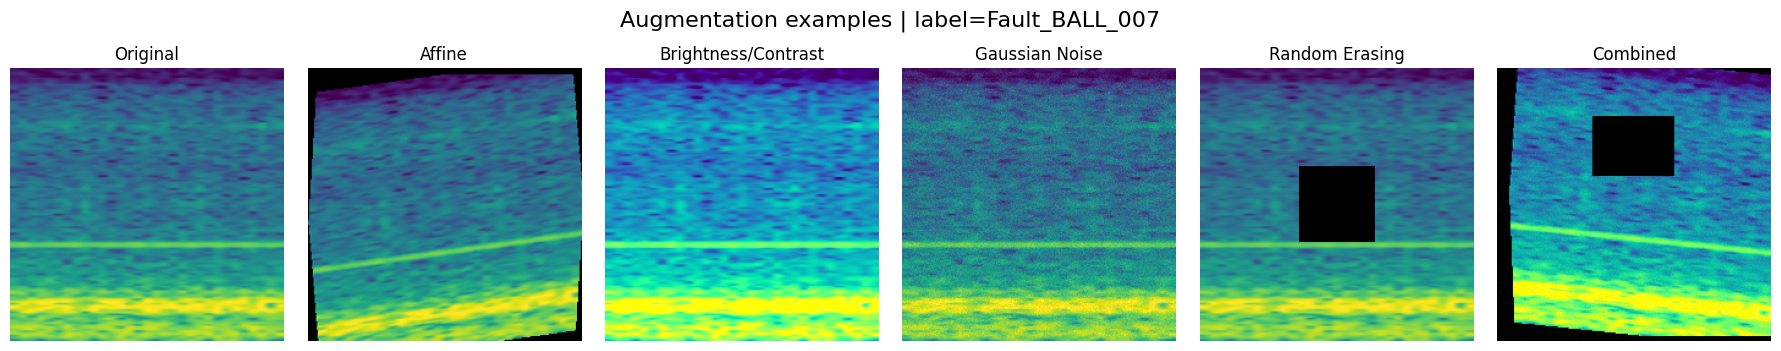

저장 완료: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures\fig_augmentation_examples_single_label.png


In [5]:
# 원하는 라벨을 지정한다.
# None이면 데이터셋에 있는 첫 번째 라벨을 자동 선택한다.
TARGET_LABEL = "Fault_BALL_007"

valid_df = metadata_df[metadata_df["exists"]].copy()

if TARGET_LABEL is not None and TARGET_LABEL in valid_df["label"].unique():
    sample_df = valid_df[valid_df["label"] == TARGET_LABEL]
else:
    TARGET_LABEL = valid_df["label"].iloc[0]
    sample_df = valid_df[valid_df["label"] == TARGET_LABEL]

# 같은 라벨 중 하나를 선택한다.
SAMPLE_INDEX = 0
row = sample_df.iloc[SAMPLE_INDEX % len(sample_df)]
original = load_image_from_row(row)

augmented = [
    ("Original", original),
    ("Affine", augment_affine(original)),
    ("Brightness/Contrast", augment_brightness_contrast(original)),
    ("Gaussian Noise", augment_gaussian_noise(original)),
    ("Random Erasing", augment_random_erasing(original, position="center")),
    ("Combined", augment_combined(original)),
]

fig, axes = plt.subplots(1, len(augmented), figsize=(18, 3.4))
for ax, (title, img) in zip(axes, augmented):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

fig.suptitle(f"Augmentation examples | label={TARGET_LABEL}", fontsize=16, y=1.02)
plt.tight_layout()

save_path = FIGURE_DIR / "fig_augmentation_examples_single_label.png"
fig.savefig(save_path, dpi=DPI, bbox_inches="tight")
plt.show()

print("저장 완료:", save_path.resolve())

## 5. 여러 클래스에 대한 증강 예시 피규어

보고서에서 데이터 증강이 특정 클래스 하나에만 적용되는 것이 아니라 전체 결함 클래스에 적용 가능하다는 점을 보여줄 때 사용한다.

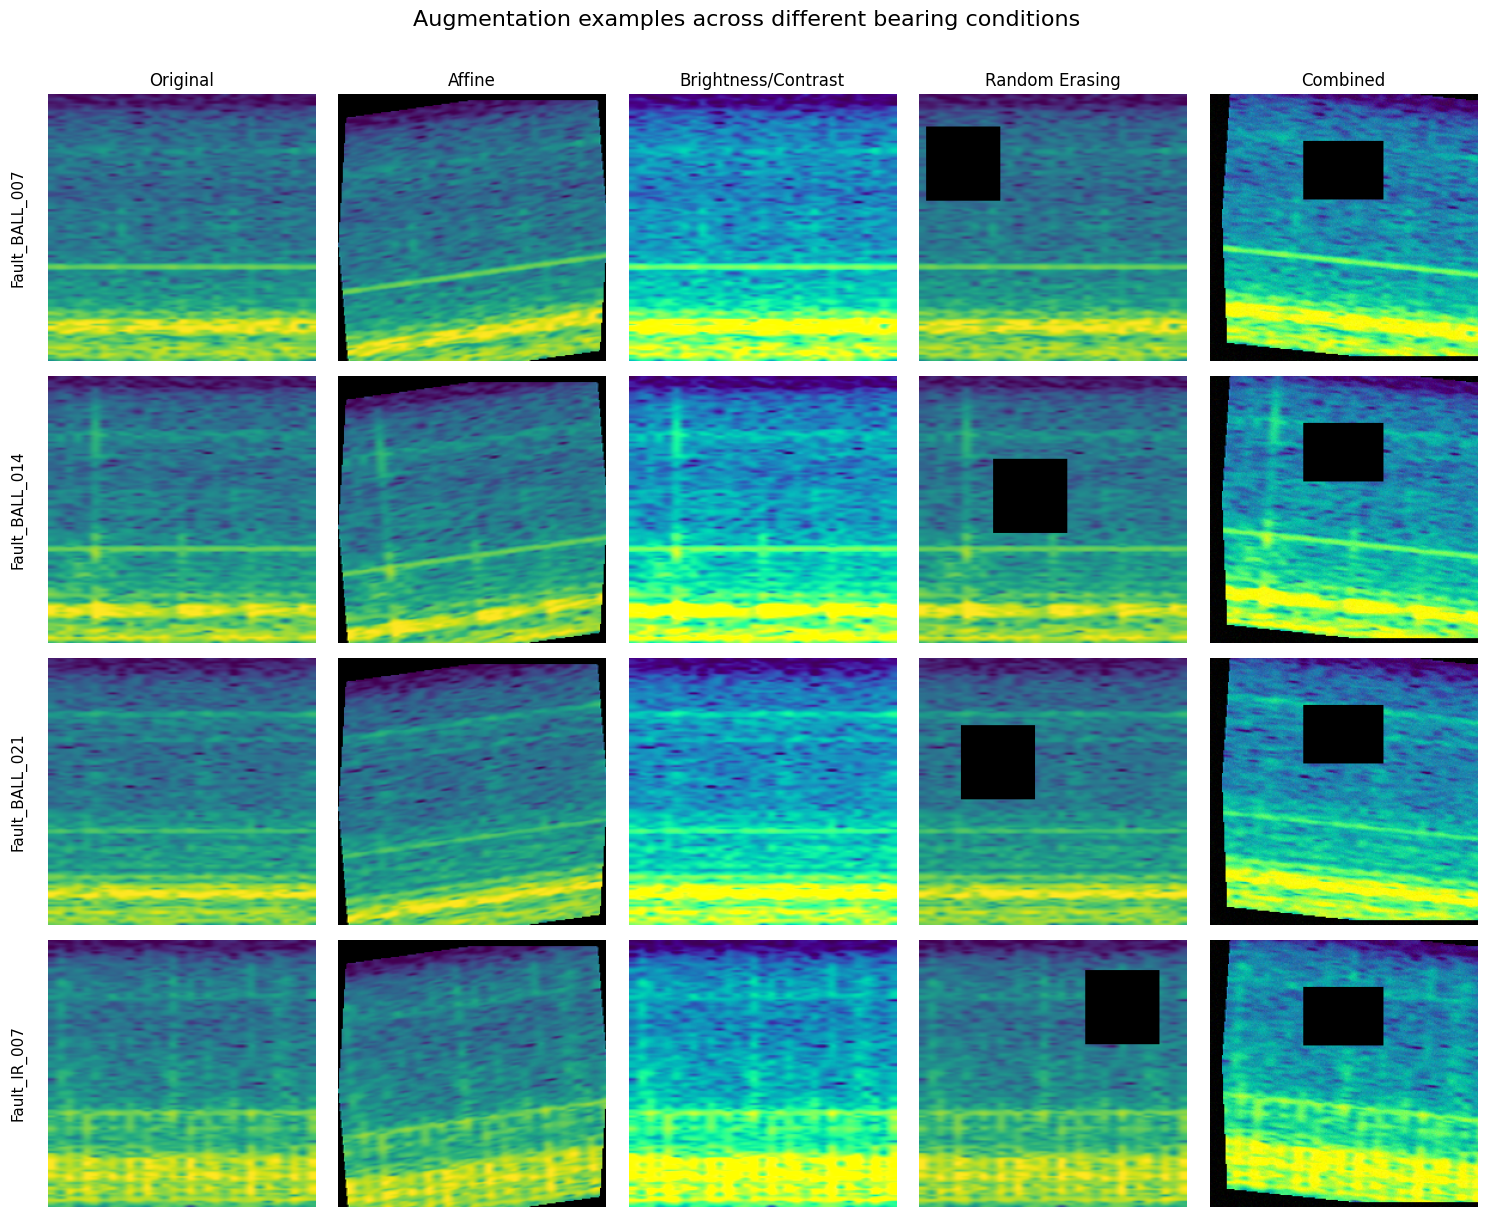

저장 완료: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures\fig_augmentation_examples_multiple_labels.png


In [6]:
# 최대 몇 개 클래스까지 보여줄지 설정
MAX_CLASSES_TO_SHOW = 4

labels = list(valid_df["label"].drop_duplicates())[:MAX_CLASSES_TO_SHOW]
cols = ["Original", "Affine", "Brightness/Contrast", "Random Erasing", "Combined"]

fig, axes = plt.subplots(len(labels), len(cols), figsize=(15, 3.0 * len(labels)))
if len(labels) == 1:
    axes = np.array([axes])

for r, label in enumerate(labels):
    row = valid_df[valid_df["label"] == label].iloc[0]
    img = load_image_from_row(row)
    imgs = [
        img,
        augment_affine(img),
        augment_brightness_contrast(img),
        augment_random_erasing(img, position="random"),
        augment_combined(img),
    ]
    for c, (col_name, aug_img) in enumerate(zip(cols, imgs)):
        ax = axes[r, c]
        ax.imshow(aug_img)
        ax.axis("off")
        if r == 0:
            ax.set_title(col_name, fontsize=12)
        if c == 0:
            ax.text(
                -0.08, 0.5, label,
                transform=ax.transAxes,
                fontsize=11,
                va="center",
                ha="right",
                rotation=90,
            )

fig.suptitle("Augmentation examples across different bearing conditions", fontsize=16, y=1.01)
plt.tight_layout()

save_path = FIGURE_DIR / "fig_augmentation_examples_multiple_labels.png"
fig.savefig(save_path, dpi=DPI, bbox_inches="tight")
plt.show()

print("저장 완료:", save_path.resolve())

## 6. 증강 강도 비교 피규어

증강 강도가 너무 약하면 일반화 효과가 작고, 너무 강하면 원래 결함 패턴을 훼손할 수 있다.
아래 피규어는 보고서에서 **적절한 augmentation strength를 선택했다**는 근거로 넣기 좋다.

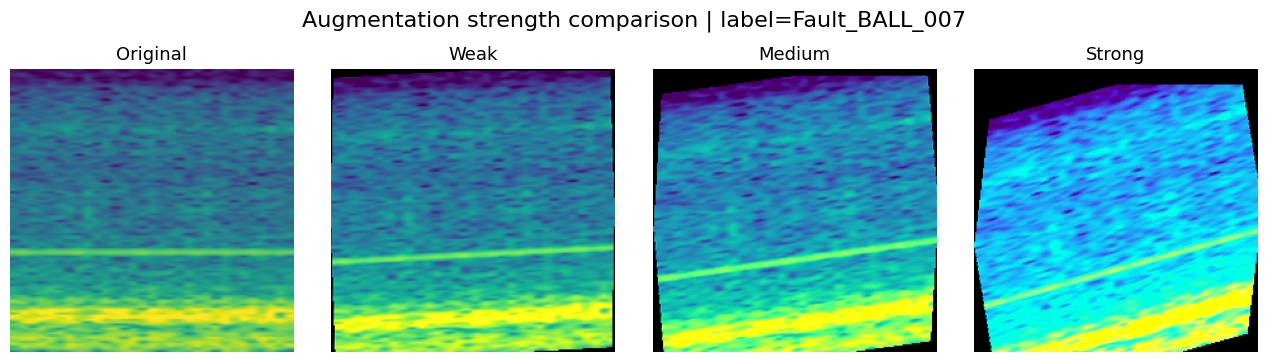

저장 완료: C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures\fig_augmentation_strength_comparison.png


In [7]:
row = sample_df.iloc[SAMPLE_INDEX % len(sample_df)]
img = load_image_from_row(row)

strength_examples = [
    ("Original", img),
    ("Weak", augment_brightness_contrast(augment_affine(img, angle=3, translate_frac=(0.01, 0.01), shear=0.02), brightness=1.08, contrast=1.10)),
    ("Medium", augment_brightness_contrast(augment_affine(img, angle=8, translate_frac=(0.04, 0.03), shear=0.06), brightness=1.20, contrast=1.25)),
    ("Strong", augment_brightness_contrast(augment_affine(img, angle=16, translate_frac=(0.08, 0.06), shear=0.12), brightness=1.45, contrast=1.55)),
]

fig, axes = plt.subplots(1, len(strength_examples), figsize=(13, 3.5))
for ax, (title, out) in zip(axes, strength_examples):
    ax.imshow(out)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

fig.suptitle(f"Augmentation strength comparison | label={TARGET_LABEL}", fontsize=16, y=1.02)
plt.tight_layout()

save_path = FIGURE_DIR / "fig_augmentation_strength_comparison.png"
fig.savefig(save_path, dpi=DPI, bbox_inches="tight")
plt.show()

print("저장 완료:", save_path.resolve())

## 7. 보고서에 넣을 설명 예시

아래 문장을 보고서에 그대로 쓰거나 조금 수정해서 사용하면 된다.

In [8]:
report_text = f"""
본 연구에서는 베어링 진동 신호를 STFT 기반 스펙트로그램 이미지로 변환한 뒤, 모델의 일반화 성능을 높이기 위해 이미지 기반 데이터 증강을 적용하였다.
사용한 증강 기법은 affine transformation, brightness/contrast adjustment, Gaussian noise, random erasing으로 구성하였다.
Affine transformation은 실제 계측 환경에서 발생할 수 있는 미세한 시간-주파수 패턴의 위치 변화를 모사하며, brightness/contrast adjustment는 신호 세기 및 스펙트럼 명암 변화에 대한 강건성을 높이기 위해 사용하였다.
Gaussian noise는 센서 계측 과정에서 발생할 수 있는 잡음을 반영하고, random erasing은 특정 주파수 영역 또는 시간 구간이 부분적으로 손상되더라도 모델이 전체적인 결함 패턴을 학습할 수 있도록 유도한다.
다만 증강 강도가 지나치게 클 경우 원래 결함 특성이 훼손될 수 있으므로, 원본 스펙트로그램의 주요 에너지 분포가 유지되는 범위에서 약한 수준의 증강을 적용하였다.
"""
print(report_text)


본 연구에서는 베어링 진동 신호를 STFT 기반 스펙트로그램 이미지로 변환한 뒤, 모델의 일반화 성능을 높이기 위해 이미지 기반 데이터 증강을 적용하였다.
사용한 증강 기법은 affine transformation, brightness/contrast adjustment, Gaussian noise, random erasing으로 구성하였다.
Affine transformation은 실제 계측 환경에서 발생할 수 있는 미세한 시간-주파수 패턴의 위치 변화를 모사하며, brightness/contrast adjustment는 신호 세기 및 스펙트럼 명암 변화에 대한 강건성을 높이기 위해 사용하였다.
Gaussian noise는 센서 계측 과정에서 발생할 수 있는 잡음을 반영하고, random erasing은 특정 주파수 영역 또는 시간 구간이 부분적으로 손상되더라도 모델이 전체적인 결함 패턴을 학습할 수 있도록 유도한다.
다만 증강 강도가 지나치게 클 경우 원래 결함 특성이 훼손될 수 있으므로, 원본 스펙트로그램의 주요 에너지 분포가 유지되는 범위에서 약한 수준의 증강을 적용하였다.



## 8. 저장된 피규어 확인

In [9]:
print("저장된 보고서용 피규어 목록")
for p in sorted(FIGURE_DIR.glob("fig_augmentation*.png")):
    print("-", p.resolve())

저장된 보고서용 피규어 목록
- C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures\fig_augmentation_examples_multiple_labels.png
- C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures\fig_augmentation_examples_single_label.png
- C:\Users\한동현\OneDrive - 중앙대학교\기계인공지능_프로젝트_코드_데이터\cwru_spectrogram_notebooks\cwru_notebook_files\cwru_spectrogram_training_dataset\report_figures\fig_augmentation_strength_comparison.png
